# WSI + Arm-Level CNV Fusion for PAM50 Subtyping of TCGA-BRCA and CPTAC-BRCA

## Problem Definition

We address 4-class **PAM50 molecular subtype classification** -- the same task as the
WSI-only report (`evaluate_pam50`), now with a second modality: arm-level copy-number
variation (CNV). Slides labelled *Normal-like* are excluded throughout.

| Class | Description |
|-------|-------------|
| **Luminal A** | Hormone receptor-positive, low proliferation |
| **Luminal B** | Hormone receptor-positive, higher proliferation |
| **Basal-like** | Triple-negative, aggressive |
| **HER2-enriched** | HER2 overexpression |

Two cohorts are in play:

- **TCGA-BRCA** -- the training cohort. Three case counts recur below and are not
  interchangeable: **945** non-Normal cases with arm-level CNV form the CNV arm's fitting
  set; **910** of them also have WSI features and a fold assignment; **599** have CLAM
  out-of-fold predictions and are the set every internal head-to-head is computed on.
- **CPTAC-BRCA** -- the external cohort: **114 cases** (378 slides). Nothing was ever
  fitted, tuned or thresholded on it; the fusion rule was fixed on TCGA before the
  external set was scored. Anything computed on CPTAC after that point is labelled
  *post hoc* where it appears.

## Pipeline

### The WSI branch

Identical to the WSI-only report: each slide is tessellated into non-overlapping patches
at 20x magnification, embedded by **UNI2-h** (1536-dimensional per patch), and classified
by **CLAM-MB** (`--model_size big`), trained with 10-fold cross-validation on TCGA. On
CPTAC the ten TCGA fold models are applied frozen to each slide, their probabilities
averaged, and slide-level probabilities mean-pooled per case.

### The CNV branch

**39 chromosome arms**, each the *median* gene-level log2 copy-number over that arm;
acrocentric p-arms (13p, 14p, 15p, 21p, 22p) are excluded by construction. The classifier
is deliberately simple: `StandardScaler` into a multinomial
`LogisticRegression(max_iter=4000, C=0.1, class_weight='balanced')`, imported from
`tools/pam50_arms.py` so this notebook and the pipeline scripts describe the same model
by construction.

Arm-level rather than focal, because shallow whole-genome sequencing resolves arm and
segment scale: the assay is cheap and clinically reachable, whereas a model over the
19,755 focal GISTIC calls in the same download would not transfer to an sWGS setting.
CNV rather than RNA, because the PAM50 labels are computed from the expression matrix
itself (`project/data/pam50.R`) -- an RNA branch predicting PAM50 leaks the target by
construction, and copy number is a different assay with no such circularity.

### The fusion rule

The equal-weight mean of the two probability vectors, `(P_wsi + P_cnv) / 2`. It is
untrained -- one line of arithmetic, nothing fitted beyond the two unimodal arms.

## Experimental Setup

Both arms are evaluated on TCGA under `splits/tcga_brca_subtyping_100` (k = 10, seed 1)
-- the split set of the frozen WSI baseline `pam50_final_s1`, reused unchanged so the
WSI-only column below is that exact model, not a retrain.

One property of this split set has to be stated plainly, and it is where this report
corrects its predecessor: **CLAM's 10 splits are drawn independently, not partitioned.**
599 of the 910 eligible cases land in at least one test fold and 242 land in two to five
(both counts recomputed below), so "WSI only" is in effect a small ensemble of up to five
fold models per case -- an audit found this flatters it by roughly +0.01 AUROC, and
re-running with a random stratified partition gave the same verdict. The WSI-only
report's claim (its section 1.3.3) that each slide appears in exactly one test fold does
not hold for this split set.

All confidence intervals are paired bootstraps: every model is scored on the same
resamples of the same cases, so each contrast is a difference over shared draws. The
head-to-head tables use 4,000 resamples at seed 7 (constants imported from
`tools/evaluate_cnv_wsi_fusion.py`); the operator ladder uses 2,000 at seed 13, mirroring
`tools/compare_fusion_ladder.py`. The protocol behind every number is stated where the
number appears.

In [1]:
import os
import pickle
import warnings

warnings.filterwarnings("ignore")
os.environ["JOBLIB_START_METHOD"] = "forkserver"

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    auc as calc_auc,
)
from sklearn.preprocessing import label_binarize

PALETTE = ["#2563EB", "#DC2626", "#16A34A", "#D97706"]
CLASS_COLORS = dict(zip(["LumA", "LumB", "Basal", "Her2"], PALETTE))

plt.rcParams.update({
    "figure.dpi": 150,
    "font.family": "sans-serif",
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "axes.labelsize": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.facecolor": "white",
})

# Shared project plumbing: the CNV model and every loader come from tools/pam50_arms.py;
# reimplementing them here is how notebook and pipeline would silently drift apart.
# `pip install -e .` puts the repository root on sys.path, so the package form resolves
# from this notebook's working directory (tools/) and from anywhere else.
import tools.pam50_arms as pam50_arms
from tools.pam50_arms import (CLASSES, CNV_C, CNV_MAX_ITER, CNV_CLASS_WEIGHT, cnv_arm,
                              load_tcga_arms, load_cptac_arms, load_cptac_wsi_probs,
                              load_clam_oof, clam_column_order, fold_train_cases,
                              macro_auroc, balanced_acc, bootstrap_indices, delta_ci,
                              renormalise, case_of)
from tools.evaluate_cnv_wsi_fusion import (N_BOOT, BOOTSTRAP_SEED, CV_FOLDS, CV_SEED,
                                           sld_em)

DISPLAY = ["LumA", "LumB", "Basal", "Her2"]         # CLAM / reference-report order
COL = {c: list(CLASSES).index(c) for c in DISPLAY}  # class -> column in CLASSES order
RESULTS_ROOT = pam50_arms.CLAM_OOF.parent
LADDER = ["concat", "gated", "cross_attention", "film_attention", "coattn"]
LADDER_N_BOOT, LADDER_BOOT_SEED = 2000, 13          # compare_fusion_ladder.py's values

print(f"helpers resolve to: {pam50_arms.__file__}")
print(f"CNV arm: StandardScaler -> LogisticRegression(max_iter={CNV_MAX_ITER},")
print(f"           C={CNV_C}, class_weight='{CNV_CLASS_WEIGHT}')")
print(f"bootstrap: {N_BOOT} resamples, seed {BOOTSTRAP_SEED} | internal CNV CV: "
      f"{CV_FOLDS}-fold, seed {CV_SEED}")
print(f"ladder bootstrap: {LADDER_N_BOOT} resamples, seed {LADDER_BOOT_SEED}")

helpers resolve to: /workspace/dp-code/tools/pam50_arms.py
CNV arm: StandardScaler -> LogisticRegression(max_iter=4000,
           C=0.1, class_weight='balanced')
bootstrap: 4000 resamples, seed 7 | internal CNV CV: 10-fold, seed 0
ladder bootstrap: 2000 resamples, seed 13


## Results

### Inputs, as read from disk

Every number below is computed in this notebook from:

- `.scratch/results/pam50_final_s1/split_{0..9}_results.pkl` -- the WSI arm, out-of-fold
- `.scratch/cptac_validation/.../ensemble_predictions.csv` -- the WSI arm on CPTAC
- `.datasets/cnv/{tcga,cptac}_brca_cna_arm.csv` -- arm-level CNV, both cohorts
- `.scratch/results/pam50_wsi_cnv_*_s1/` -- the five trained ladder runs

Two class orders are in play in those files (CLAM's `LumA, LumB, Basal, Her2` against
`pam50_arms.CLASSES`'s sorted `Basal, Her2, LumA, LumB`); the recovered mapping is
printed and asserted to be a permutation before anything is scored.

In [2]:
X_tcga, y_tcga = load_tcga_arms()                    # the CNV arm's fitting set
tabular = pd.read_csv(pam50_arms.CNV_TABULAR_DIR / "TCGA_BRCA_CNV_arm_4class_clam.csv")
oof = load_clam_oof(with_folds=True)                 # CLAM out-of-fold, pooled per case
int_cases = list(X_tcga.index.intersection(oof.index))
oof_int, y_int = oof.loc[int_cases], y_tcga.loc[int_cases]

clam_order = clam_column_order(oof_int, y_int)       # asserted to be a permutation
perm = [clam_order.index(c) for c in CLASSES]
Pw_int = oof_int[[f"p{i}" for i in range(4)]].values[:, perm]

wsi_cptac, n_slides = load_cptac_wsi_probs()         # slide -> case mean-pooled
X_cptac = load_cptac_arms()

folds_per_case = {}                                  # split multiplicity, recomputed
for path in sorted(pam50_arms.CLAM_OOF.glob("split_*_results.pkl")):
    for slide in pickle.load(open(path, "rb")):
        folds_per_case.setdefault(case_of(slide), set()).add(path.stem)
n_folds_tested = pd.Series({c: len(f) for c, f in folds_per_case.items()})

cts = lambda y: pd.Series(y).value_counts().reindex(DISPLAY).to_dict()
inventory = pd.DataFrame([
    {"case set": "TCGA: CNV fitting set (non-Normal, arm CNV)",
     "n": len(y_tcga), **cts(y_tcga)},
    {"case set": "TCGA: CLAM tabular table (CNV + WSI + fold)",
     "n": len(tabular), **cts(tabular["label"])},
    {"case set": "TCGA: with CLAM out-of-fold predictions",
     "n": len(int_cases), **cts(y_int)},
    {"case set": "CPTAC: external cases",
     "n": len(wsi_cptac), **cts(wsi_cptac["true_name"])},
])

print("Table 1: Cohort inventory -- three TCGA counts, none interchangeable")
print("=" * 76)
print(inventory.to_string(index=False))
print("-" * 76)
print(f"  CPTAC probabilities read from {n_slides} slide rows, mean-pooled per case")
print(f"  split multiplicity: {int((n_folds_tested == 1).sum())} cases tested by "
      f"exactly 1 fold, {int((n_folds_tested >= 2).sum())} by "
      f"{int(n_folds_tested[n_folds_tested >= 2].min())}-{int(n_folds_tested.max())}")
print(f"  CLAM class order recovered: {clam_order}")
print(f"  scoring order (CLASSES):    {list(CLASSES)}")
print("=" * 76)

Table 1: Cohort inventory -- three TCGA counts, none interchangeable
                                   case set   n  LumA  LumB  Basal  Her2
TCGA: CNV fitting set (non-Normal, arm CNV) 945   499   197    171    78
TCGA: CLAM tabular table (CNV + WSI + fold) 910   475   195    165    75
    TCGA: with CLAM out-of-fold predictions 599   318   124    106    51
                      CPTAC: external cases 114    56    17     27    14
----------------------------------------------------------------------------
  CPTAC probabilities read from 378 slide rows, mean-pooled per case
  split multiplicity: 357 cases tested by exactly 1 fold, 242 by 2-5
  CLAM class order recovered: ['LumA', 'LumB', 'Basal', 'Her2']
  scoring order (CLASSES):    ['Basal', 'Her2', 'LumA', 'LumB']


### Internal TCGA head-to-head -- 599 cases, both arms out-of-fold

WSI probabilities are `pam50_final_s1`'s pooled out-of-fold predictions. The CNV arm is
refit per CLAM fold -- trained on that fold's training cases, applied to its held-out
cases -- so **both arms are out-of-fold on the same folds of the same 599 cases**; of the
three defensible internal CNV protocols (all measured in the next table), that matching
is why this one is the figure the report carries. Paired bootstrap, 4,000 resamples,
seed 7. The recall columns are counts at argmax.

In [3]:
folds_int = oof_int["fold"].values
Pc_int = np.zeros_like(Pw_int)
for fold in np.unique(folds_int):
    train = X_tcga.index.isin(fold_train_cases(fold) & set(X_tcga.index))
    held = folds_int == fold
    Pc_int[held] = cnv_arm().fit(X_tcga[train], y_tcga[train]).predict_proba(
        X_tcga.loc[np.array(int_cases)[held]])
Pm_int = (Pw_int + Pc_int) / 2
yv_int = y_int.values


def boot_scores(y, models, n_boot, seed):
    """Macro AUROC and balanced accuracy per model, on shared bootstrap resamples."""
    idx = bootstrap_indices(y, n_boot, seed)
    return {name: np.array([[macro_auroc(y[j], P[j]), balanced_acc(y[j], P[j])]
                            for j in idx])
            for name, P in models.items()}


def recall_str(y, P, c):
    pred = CLASSES[P.argmax(1)]
    return f"{int(((pred == c) & (y == c)).sum())}/{int((y == c).sum())}"


def model_table(y, models, scores):
    rows = []
    for name, P in models.items():
        lo, hi = np.percentile(scores[name][:, 0], [2.5, 97.5])
        rows.append({"model": name,
                     "AUROC": f"{macro_auroc(y, P):.3f}",
                     "95% CI": f"[{lo:.3f}, {hi:.3f}]",
                     "balAcc": f"{balanced_acc(y, P):.3f}",
                     **{c: recall_str(y, P, c) for c in DISPLAY}})
    print(pd.DataFrame(rows).to_string(index=False))


def contrast(scores, a, b, label=None, note=""):
    cells = []
    for k in (0, 1):
        m, lo, hi, verdict = delta_ci(scores[a][:, k], scores[b][:, k])
        cells.append(f"{m:+.3f} [{lo:+.3f},{hi:+.3f}] {verdict:3s}")
    print(f"  {label or a + ' - ' + b:18s}{cells[0]}  {cells[1]}{note}")


int_models = {"WSI": Pw_int, "CNV": Pc_int, "Mean": Pm_int}
print("Table 2: Internal TCGA head-to-head (599 cases, CNV refit per CLAM fold)")
print("=" * 76)
int_scores = boot_scores(yv_int, int_models, N_BOOT, BOOTSTRAP_SEED)
model_table(yv_int, int_models, int_scores)
print("-" * 76)
print(f"  {'contrast':18s}{'dAUROC [95% CI]':28s}{'dBalAcc [95% CI]'}")
contrast(int_scores, "Mean", "WSI")
contrast(int_scores, "Mean", "CNV")
contrast(int_scores, "WSI", "CNV")
print("=" * 76)

Table 2: Internal TCGA head-to-head (599 cases, CNV refit per CLAM fold)


model AUROC         95% CI balAcc    LumA   LumB   Basal  Her2
  WSI 0.887 [0.865, 0.908]  0.677 257/318 66/124  91/106 26/51
  CNV 0.872 [0.848, 0.895]  0.678 231/318 78/124  92/106 25/51
 Mean 0.926 [0.909, 0.941]  0.751 263/318 79/124 101/106 30/51
----------------------------------------------------------------------------
  contrast          dAUROC [95% CI]             dBalAcc [95% CI]
  Mean - WSI        +0.039 [+0.024,+0.054] sig  +0.074 [+0.028,+0.122] sig
  Mean - CNV        +0.054 [+0.036,+0.072] sig  +0.073 [+0.031,+0.116] sig
  WSI - CNV         +0.015 [-0.014,+0.045] ns   -0.001 [-0.065,+0.065] ns 


### One internal CNV figure, three defensible protocols

Three internal CNV-only figures circulate in this project's documents, and the spread
between them is larger than contrasts this report calls significant, so the protocol is
pinned rather than left to the reader: the per-CLAM-fold refit above is the nominated
figure **because it is the only protocol under which both arms are out-of-fold on the
same folds**. The other two are recomputed here so any previously seen number can be
placed.

In [4]:
from sklearn.model_selection import StratifiedKFold, cross_val_predict

auc_fold = macro_auroc(yv_int, Pc_int)               # (a) nominated, from Table 2

Pc_skf = cross_val_predict(                          # (b) evaluate_cnv_wsi_fusion.py
    cnv_arm(), X_tcga.loc[int_cases], y_int,         #     --internal protocol
    cv=StratifiedKFold(CV_FOLDS, shuffle=True, random_state=CV_SEED),
    method="predict_proba")
auc_skf = macro_auroc(yv_int, Pc_skf)

seed_aucs = np.array([                               # (c) the published headline
    macro_auroc(y_tcga, cross_val_predict(
        cnv_arm(), X_tcga, y_tcga,
        cv=StratifiedKFold(5, shuffle=True, random_state=s),
        method="predict_proba"))
    for s in range(10)])

print("Table 3: The internal CNV-only macro AUROC under its three protocols")
print("=" * 76)
print(f"  {auc_fold:.4f}            refit per CLAM fold, 599 cases"
      "      << carried here")
print(f"  {auc_skf:.4f}            StratifiedKFold({CV_FOLDS}, seed {CV_SEED}), "
      "599 cases")
print(f"  {seed_aucs.mean():.4f} +- {seed_aucs.std():.4f}  5-fold CV x 10 seeds "
      "(0-9), 945 cases  << published")
print("=" * 76)

Table 3: The internal CNV-only macro AUROC under its three protocols
  0.8721            refit per CLAM fold, 599 cases      << carried here
  0.8624            StratifiedKFold(10, seed 0), 599 cases
  0.8657 +- 0.0034  5-fold CV x 10 seeds (0-9), 945 cases  << published


### External validation on CPTAC -- the headline table

The CNV arm is fit once on all 945 TCGA cases and applied to CPTAC unchanged; the WSI
arm's CPTAC probabilities are read from the frozen inference run. The first three rows
were specified before CPTAC was scored. The fourth was not: the prior-balanced mean
divides the WSI probabilities by the TCGA training prior before averaging (the CNV arm
is class-balanced by construction, the WSI arm is not) and was run **post hoc**, after
the raw fusion underperformed on balanced accuracy -- it is a decision-rule control, not
the pre-registered analysis. The headline contrast is therefore fusion against raw WSI,
marked below; fusion against CNV alone is printed beside it every time, because that
margin is the marginal one.

In [5]:
clf_ext = cnv_arm().fit(X_tcga, y_tcga)
ext_cases = sorted(set(wsi_cptac.index) & set(X_cptac.index))
y_ext = wsi_cptac.loc[ext_cases, "true_name"].values
Pw_ext = wsi_cptac.loc[ext_cases, [f"p_{c}" for c in CLASSES]].values
Pc_ext = clf_ext.predict_proba(X_cptac.loc[ext_cases, X_tcga.columns])
keep = np.isin(y_ext, CLASSES)
y_ext, Pw_ext, Pc_ext = y_ext[keep], Pw_ext[keep], Pc_ext[keep]

prior = np.array([(y_tcga == c).mean() for c in CLASSES])
Pwb_ext = renormalise(Pw_ext / prior)                # post-hoc decision-rule control
ext_models = {"WSI": Pw_ext, "CNV": Pc_ext,
              "Mean": (Pw_ext + Pc_ext) / 2,
              "Mean(bal) post hoc": (Pwb_ext + Pc_ext) / 2}

print(f"external set: {len(y_ext)} cases")
print("TCGA training prior: "
      + "  ".join(f"{c} {prior[COL[c]]:.3f}" for c in DISPLAY))
print()
print("Table 4: External CPTAC -- TCGA-trained, nothing refit or tuned on CPTAC")
print("=" * 76)
ext_scores = boot_scores(y_ext, ext_models, N_BOOT, BOOTSTRAP_SEED)
model_table(y_ext, ext_models, ext_scores)
print("-" * 76)
print(f"  {'contrast':18s}{'dAUROC [95% CI]':28s}{'dBalAcc [95% CI]'}")
contrast(ext_scores, "Mean", "WSI", note=" *")
contrast(ext_scores, "Mean", "CNV")
contrast(ext_scores, "CNV", "WSI")
contrast(ext_scores, "Mean(bal) post hoc", "Mean", label="Mean(bal) - Mean")
contrast(ext_scores, "Mean(bal) post hoc", "CNV", label="Mean(bal) - CNV")
print("  * the pre-specified headline contrast; Mean(bal) rows are post hoc")
print("=" * 76)
print()

# The Her2 rescue control: is 0/14 a threshold artifact? Boost the prior and re-ask.
h2 = lambda P: recall_str(y_ext, P, "Her2")
pi_sld = sld_em(Pw_ext, prior)                       # unsupervised prior estimation
her2 = COL["Her2"]
print(f"Her2 rescue control (WSI arm): raw {h2(Pw_ext)}, prior-balanced "
      f"({1 / prior[her2]:.0f}x) {h2(Pwb_ext)},")
print(f"  SLD-EM {h2(renormalise(Pw_ext * (pi_sld / prior)))} "
      f"(estimated Her2 prior {pi_sld[her2]:.3f} against a true "
      f"{(y_ext == 'Her2').mean():.3f})")

correct_w = (CLASSES[Pw_ext.argmax(1)] == y_ext).astype(float)
correct_c = (CLASSES[Pc_ext.argmax(1)] == y_ext).astype(float)
phi_ext = float(np.corrcoef(correct_w, correct_c)[0, 1])
print(f"error correlation phi(WSI, CNV), external, independent arms: "
      f"{phi_ext:+.3f}")

external set: 114 cases
TCGA training prior: LumA 0.528  LumB 0.208  Basal 0.181  Her2 0.083

Table 4: External CPTAC -- TCGA-trained, nothing refit or tuned on CPTAC


             model AUROC         95% CI balAcc  LumA  LumB Basal  Her2
               WSI 0.847 [0.793, 0.897]  0.513 52/56  4/17 24/27  0/14
               CNV 0.888 [0.833, 0.935]  0.716 37/56  9/17 22/27 12/14
              Mean 0.909 [0.861, 0.949]  0.646 50/56  7/17 23/27  6/14
Mean(bal) post hoc 0.912 [0.864, 0.952]  0.740 43/56 10/17 24/27 10/14
----------------------------------------------------------------------------
  contrast          dAUROC [95% CI]             dBalAcc [95% CI]
  Mean - WSI        +0.063 [+0.024,+0.104] sig  +0.133 [+0.031,+0.240] sig *
  Mean - CNV        +0.021 [-0.003,+0.047] ns   -0.069 [-0.165,+0.022] ns 
  CNV - WSI         +0.042 [-0.019,+0.103] ns   +0.202 [+0.089,+0.315] sig
  Mean(bal) - Mean  +0.003 [-0.005,+0.011] ns   +0.093 [+0.014,+0.177] sig
  Mean(bal) - CNV   +0.024 [+0.000,+0.050] sig  +0.024 [-0.055,+0.099] ns 
  * the pre-specified headline contrast; Mean(bal) rows are post hoc

Her2 rescue control (WSI arm): raw 0/14, prior-balanced 

### Per-class external performance

Per-class one-vs-rest AUROC and recall at argmax on the same 114 cases. Her2 is where
the modalities part company: by *ranking* the two arms are comparable, but the WSI arm
converts none of it into calls -- and the rescue control above shows no monotone prior
reweighting changes that, so it is not a threshold artifact. The class supports (Her2
n = 14, LumB n = 17) are printed with the table; at that n these per-class figures are
indicative, not precise.

In [6]:
print("Table 5: External per-class AUROC (one-vs-rest) and recall at argmax")
print("=" * 76)
auc_rows, rec_rows = [], []
for name, P in ext_models.items():
    auc_rows.append({"model": name, **{
        c: f"{roc_auc_score((y_ext == c).astype(int), P[:, COL[c]]):.3f}"
        for c in DISPLAY}})
    rec_rows.append({"model": name, **{c: recall_str(y_ext, P, c) for c in DISPLAY}})
print("one-vs-rest AUROC:")
print(pd.DataFrame(auc_rows).to_string(index=False))
print()
print("recall at argmax:")
print(pd.DataFrame(rec_rows).to_string(index=False))
print("-" * 76)
print("  class support: "
      + "  ".join(f"{c} n={int((y_ext == c).sum())}" for c in DISPLAY))
print("=" * 76)

Table 5: External per-class AUROC (one-vs-rest) and recall at argmax
one-vs-rest AUROC:
             model  LumA  LumB Basal  Her2
               WSI 0.861 0.693 0.972 0.860
               CNV 0.883 0.827 0.972 0.871
              Mean 0.916 0.848 0.992 0.881
Mean(bal) post hoc 0.918 0.848 0.990 0.893

recall at argmax:
             model  LumA  LumB Basal  Her2
               WSI 52/56  4/17 24/27  0/14
               CNV 37/56  9/17 22/27 12/14
              Mean 50/56  7/17 23/27  6/14
Mean(bal) post hoc 43/56 10/17 24/27 10/14
----------------------------------------------------------------------------
  class support: LumA n=56  LumB n=17  Basal n=27  Her2 n=14


### Confusion matrix, external equal-weight mean

Figure 1 shows where the fused model's external decisions land, as raw counts (left) and
row-normalised recall (right). The Her2 row is the one to read: the fusion keeps 6 of 14
under the raw WSI decision rule, against the CNV arm's 12 of 14 (Table 5).

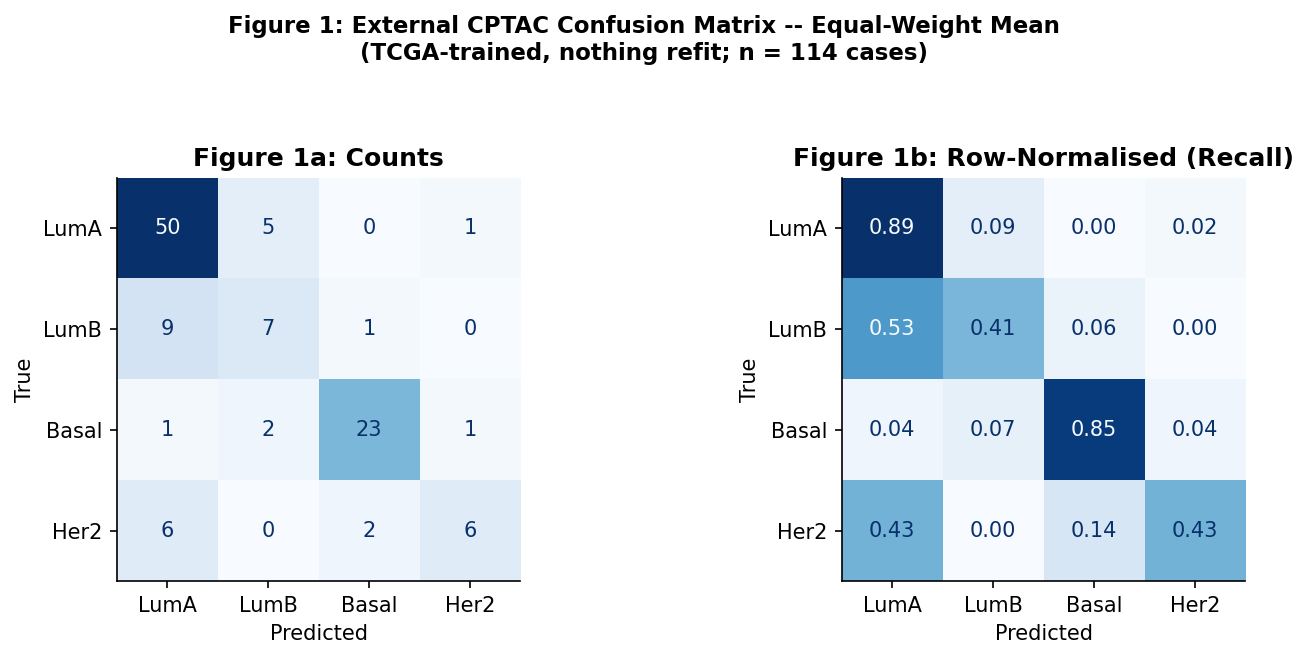

In [7]:
pred_mean = CLASSES[ext_models["Mean"].argmax(1)]
cm_raw = confusion_matrix(y_ext, pred_mean, labels=DISPLAY)
cm_norm = cm_raw.astype(float) / cm_raw.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(10, 4.1))

ConfusionMatrixDisplay(cm_raw, display_labels=DISPLAY).plot(
    ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title("Figure 1a: Counts")

ConfusionMatrixDisplay(cm_norm, display_labels=DISPLAY).plot(
    ax=axes[1], cmap="Blues", colorbar=False, values_format=".2f")
axes[1].set_title("Figure 1b: Row-Normalised (Recall)")

for a in axes:
    a.set_xlabel("Predicted")
    a.set_ylabel("True")

fig.suptitle("Figure 1: External CPTAC Confusion Matrix -- Equal-Weight Mean\n"
             "(TCGA-trained, nothing refit; n = 114 cases)",
             fontweight="bold", fontsize=11, y=1.06)
fig.tight_layout()
plt.show()

### ROC curves, external equal-weight mean

Figure 2 shows one-vs-rest ROC curves for the equal-weight mean on the 114 external
cases. Ranking survives transfer for every class -- including Her2, whose curve sits
near the CNV arm's despite the argmax collapse of the WSI branch.

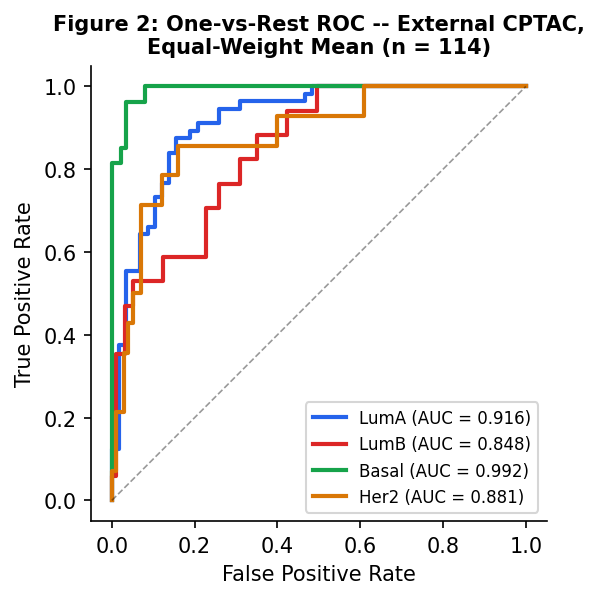

In [8]:
fig, ax = plt.subplots(figsize=(4.5, 4.1))

ext_class_aucs = {}
for name in DISPLAY:
    fpr, tpr, _ = roc_curve((y_ext == name).astype(int),
                            ext_models["Mean"][:, COL[name]])
    ext_class_aucs[name] = calc_auc(fpr, tpr)
    ax.plot(fpr, tpr, color=CLASS_COLORS[name], lw=2,
            label=f"{name} (AUC = {ext_class_aucs[name]:.3f})")

ax.plot([0, 1], [0, 1], "k--", lw=0.8, alpha=0.4)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("Figure 2: One-vs-Rest ROC -- External CPTAC,\n"
             "Equal-Weight Mean (n = 114)", fontsize=10)
ax.legend(fontsize=8, loc="lower right")
ax.set_aspect("equal")
fig.tight_layout()
plt.show()

### The fusion-operator ladder -- internal only

Five trained fusion operators -- concat, gated, cross_attention, film_attention, coattn
-- were run on the same splits (CLAM-MB, the WSI branch warm-started from
`pam50_final_s1` and not frozen, k = 10, seed 1). They are compared as pooled
out-of-fold predictions over the 599 cases all runs share, with a 2,000-resample paired
bootstrap at seed 13, mirroring `tools/compare_fusion_ladder.py`. **The baseline each
operator is read against is the equal-weight mean, not the WSI-only model.**

Where a reader would expect an external CPTAC column for these five rows: there is none,
and none can currently be produced. `project/CLAM/evaluate_multimodal.py` has no loading
path for `film_attention` or `coattn` checkpoints (the former raises in fusion-mode
inference, the latter is misidentified as `cross_attention` and fails
`load_state_dict(strict=True)`), so the ladder is an internal-only result by
construction and the external table above keeps exactly four model rows.

The mechanism check under the table contrasts two error-correlation regimes, both
internal and pooled out-of-fold: phi among the five jointly trained operators against
phi between the two independently trained unimodal arms (CNV per-CLAM-fold refit).
Models sharing a trunk and an initialisation make the same mistakes, so ensembling them
recovers little; the two independent arms err nearly independently, which is the signal
the untrained mean exploits.

In [9]:
def load_run(run_dir):
    """Pooled per-case OOF probabilities of one CLAM run (compare_fusion_ladder.py's
    loader)."""
    rows = []
    for path in sorted(run_dir.glob("split_*_results.pkl")):
        for slide, rec in pickle.load(open(path, "rb")).items():
            rows.append({"case_id": case_of(slide),
                         **{f"p{i}": p
                            for i, p in enumerate(np.asarray(rec["prob"]).ravel())}})
    return pd.DataFrame(rows).groupby("case_id").agg("mean")


ladder_runs = {m: load_run(RESULTS_ROOT / f"pam50_wsi_cnv_{m}_s1") for m in LADDER}
shared = sorted(set(oof_int.index)
                .intersection(*(set(r.index) for r in ladder_runs.values()))
                & set(X_tcga.index))
assert set(shared) == set(int_cases), "ladder runs cover a different case set"
y_lad = y_tcga.loc[shared].values

pos = [int_cases.index(c) for c in shared]           # realign Table 2's arrays
lad_probs = {"WSI only": Pw_int[pos], "CNV only": Pc_int[pos],
             "probability mean": Pm_int[pos]}
for m, run in ladder_runs.items():
    lad_probs[m] = run.loc[shared, [f"p{i}" for i in range(4)]].values[:, perm]

lad_scores = boot_scores(y_lad, lad_probs, LADDER_N_BOOT, LADDER_BOOT_SEED)
rows = []
for name in ["WSI only", "CNV only", "probability mean", *LADDER]:
    lo, hi = np.percentile(lad_scores[name][:, 0], [2.5, 97.5])
    if name == "probability mean":
        d = "--  (the baseline)"
    else:
        m_, dlo, dhi, verdict = delta_ci(lad_scores[name][:, 0],
                                         lad_scores["probability mean"][:, 0])
        d = f"{m_:+.4f} [{dlo:+.4f},{dhi:+.4f}] {verdict}"
    rows.append({"arm": name,
                 "AUROC": f"{macro_auroc(y_lad, lad_probs[name]):.4f}",
                 "95% CI": f"[{lo:.3f}, {hi:.3f}]",
                 "balAcc": f"{balanced_acc(y_lad, lad_probs[name]):.4f}",
                 "dAUROC vs mean": d})
print(f"Table 6: Fusion-operator ladder, pooled OOF ({len(shared)} internal cases)")
print("=" * 76)
print(pd.DataFrame(rows).to_string(index=False))
print("-" * 76)
dbal = {name: delta_ci(lad_scores[name][:, 1],
                       lad_scores["probability mean"][:, 1])
        for name in lad_probs if name != "probability mean"}
print(f"  dBalAcc vs mean: {sum(v[3] == 'sig' for v in dbal.values())}/{len(dbal)} "
      f"arms significant,")
print(f"      deltas {min(v[0] for v in dbal.values()):+.3f} to "
      f"{max(v[0] for v in dbal.values()):+.3f} (all below the mean)")
print()
correct = {n: (CLASSES[P.argmax(1)] == y_lad).astype(float)
           for n, P in lad_probs.items()}
op_phis = [np.corrcoef(correct[a], correct[b])[0, 1]
           for i, a in enumerate(LADDER) for b in LADDER[i + 1:]]
phi_uni = float(np.corrcoef(correct["WSI only"], correct["CNV only"])[0, 1])
print("error correlation phi -- each value labelled with its regime:")
print(f"  5 jointly trained operators, internal pooled OOF, 10 pairs: "
      f"mean {np.mean(op_phis):.3f}")
print(f"      (min {min(op_phis):.3f}, max {max(op_phis):.3f})")
print(f"  WSI-only vs CNV-only, internal, CNV per-CLAM-fold refit:    "
      f"{phi_uni:.3f}")
print(f"  WSI-only vs CNV-only, external CPTAC (from Table 4's arms): "
      f"{phi_ext:+.3f}")
print("=" * 76)

Table 6: Fusion-operator ladder, pooled OOF (599 internal cases)
             arm  AUROC         95% CI balAcc                dAUROC vs mean
        WSI only 0.8872 [0.867, 0.909] 0.6772 -0.0386 [-0.0544,-0.0234] sig
        CNV only 0.8721 [0.848, 0.895] 0.6784 -0.0541 [-0.0732,-0.0371] sig
probability mean 0.9259 [0.910, 0.941] 0.7513            --  (the baseline)
          concat 0.8827 [0.859, 0.906] 0.6741 -0.0430 [-0.0630,-0.0256] sig
           gated 0.8947 [0.875, 0.915] 0.6832 -0.0311 [-0.0477,-0.0161] sig
 cross_attention 0.8917 [0.869, 0.914] 0.6848 -0.0342 [-0.0541,-0.0156] sig
  film_attention 0.8818 [0.861, 0.903] 0.6652 -0.0438 [-0.0618,-0.0271] sig
          coattn 0.8992 [0.879, 0.919] 0.6842 -0.0267 [-0.0432,-0.0106] sig
----------------------------------------------------------------------------
  dBalAcc vs mean: 7/7 arms significant,
      deltas -0.086 to -0.066 (all below the mean)

error correlation phi -- each value labelled with its regime:
  5 jointly trained

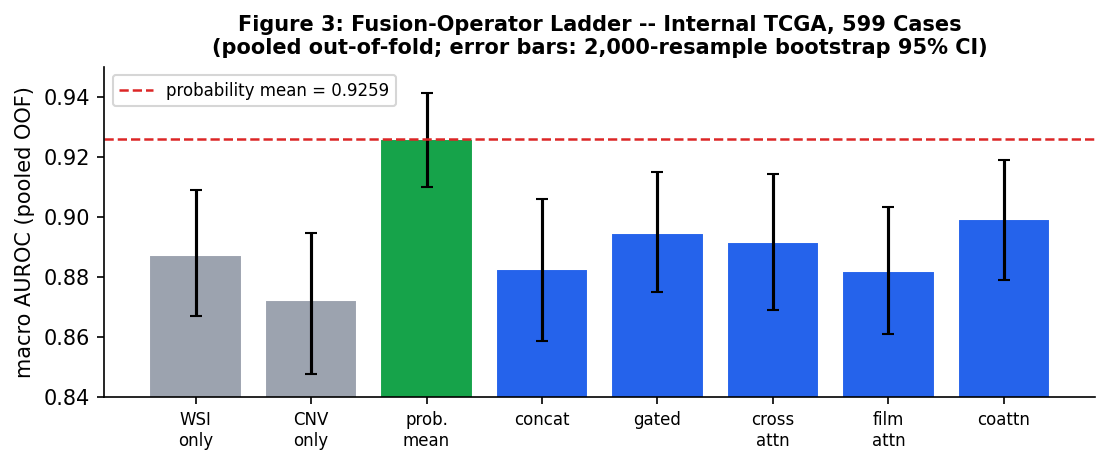

In [10]:
arm_order = ["WSI only", "CNV only", "probability mean", *LADDER]
aucs = np.array([macro_auroc(y_lad, lad_probs[a]) for a in arm_order])
ci = np.array([np.percentile(lad_scores[a][:, 0], [2.5, 97.5]) for a in arm_order])
colors = ["#9CA3AF", "#9CA3AF", "#16A34A"] + ["#2563EB"] * len(LADDER)

fig, ax = plt.subplots(figsize=(7.5, 3.2))
x = np.arange(len(arm_order))
ax.bar(x, aucs, yerr=[aucs - ci[:, 0], ci[:, 1] - aucs],
       color=colors, edgecolor="white", capsize=3)
mean_auc = aucs[arm_order.index("probability mean")]
ax.axhline(mean_auc, color="#DC2626", ls="--", lw=1.2,
           label=f"probability mean = {mean_auc:.4f}")
ax.set_xticks(x)
ax.set_xticklabels(["WSI\nonly", "CNV\nonly", "prob.\nmean", "concat", "gated",
                    "cross\nattn", "film\nattn", "coattn"], fontsize=8)
ax.set_ylabel("macro AUROC (pooled OOF)")
ax.set_ylim([0.84, 0.95])
ax.set_title("Figure 3: Fusion-Operator Ladder -- Internal TCGA, 599 Cases\n"
             "(pooled out-of-fold; error bars: 2,000-resample bootstrap 95% CI)",
             fontsize=10)
ax.legend(fontsize=8, loc="upper left")
fig.tight_layout()
plt.show()

## Summary

The closing block gathers the four external rows, the internal comparison, and the
verdict.

In [11]:
op_aucs = {m: macro_auroc(y_lad, lad_probs[m]) for m in LADDER}

print("=" * 72)
print("  WSI + arm-level CNV | 4-class PAM50 | trained on TCGA, external CPTAC")
print("=" * 72)
print(f"--- External CPTAC, n = {len(y_ext)} cases "
      f"({N_BOOT}-resample paired bootstrap) ---")
for name, P in ext_models.items():
    lo, hi = np.percentile(ext_scores[name][:, 0], [2.5, 97.5])
    print(f"  {name:20s}  AUROC {macro_auroc(y_ext, P):.3f} [{lo:.3f}, {hi:.3f}]"
          f"  bal {balanced_acc(y_ext, P):.3f}  Her2 {recall_str(y_ext, P, 'Her2'):>5s}")
print()
print("--- Per-class, equal-weight mean (external) ---")
print(f"  {'Class':6s}  {'AUROC':>6s}  {'Recall':>7s}")
for c in DISPLAY:
    print(f"  {c:6s}  {ext_class_aucs[c]:6.3f}  "
          f"{recall_str(y_ext, ext_models['Mean'], c):>7s}")
print()
print("--- Internal TCGA, 599 cases (CNV refit per CLAM fold) ---")
print(f"  WSI {macro_auroc(yv_int, Pw_int):.4f}   CNV {macro_auroc(yv_int, Pc_int):.4f}"
      f"   equal-weight mean {macro_auroc(yv_int, Pm_int):.4f}")
print(f"  trained operators (5): {min(op_aucs.values()):.4f} - "
      f"{max(op_aucs.values()):.4f}, all significantly below")
print("  the mean (internal only; no external evaluation path exists)")
print()
print("VERDICT: conditioning H&E on copy number does not beat averaging two")
print("independently trained predictions. The equal-weight mean is the best model")
print("internally and externally; every trained operator sits significantly below")
print("it. Fusion's edge over CNV alone is marginal -- report both (Table 4).")
print("=" * 72)

  WSI + arm-level CNV | 4-class PAM50 | trained on TCGA, external CPTAC
--- External CPTAC, n = 114 cases (4000-resample paired bootstrap) ---
  WSI                   AUROC 0.847 [0.793, 0.897]  bal 0.513  Her2  0/14
  CNV                   AUROC 0.888 [0.833, 0.935]  bal 0.716  Her2 12/14
  Mean                  AUROC 0.909 [0.861, 0.949]  bal 0.646  Her2  6/14
  Mean(bal) post hoc    AUROC 0.912 [0.864, 0.952]  bal 0.740  Her2 10/14

--- Per-class, equal-weight mean (external) ---
  Class    AUROC   Recall
  LumA     0.916    50/56
  LumB     0.848     7/17
  Basal    0.992    23/27
  Her2     0.881     6/14

--- Internal TCGA, 599 cases (CNV refit per CLAM fold) ---
  WSI 0.8872   CNV 0.8721   equal-weight mean 0.9259
  trained operators (5): 0.8818 - 0.8992, all significantly below
  the mean (internal only; no external evaluation path exists)

VERDICT: conditioning H&E on copy number does not beat averaging two
independently trained predictions. The equal-weight mean is the best m

## Limitations

The external Her2 collapse is the report's most consequential finding and its clearest
limitation. The WSI arm calls 0 of 14 Her2 cases on CPTAC while calling 26 of 51
internally (Table 2), and the calibration explanation was tested and refuted in the
rescue control under Table 4: recall stays 0/14 after dividing by the training prior (a
roughly 12x Her2 boost) and under unsupervised SLD-EM prior estimation, which drives the
implied Her2 prior to zero against a true 0.123. The collapse is induced by the domain
shift, so remediation belongs on the imaging side -- stain normalisation, encoder choice
-- not in recalibration.

Power is thin exactly where the story is. Her2 has 14 external cases and LumB 17, so
per-class external estimates are indicative rather than precise, and the 12-of-14
against 0-of-14 contrast, however striking, rests on 14 cases.

The two cohorts' features are geometrically comparable but not identically produced: the
CPTAC `.h5` files carry CLAM `create_patches_fp` attributes while TCGA's carry Trident
ones, so tissue segmentation -- and therefore which tiles enter each bag -- differs
between cohorts. That difference is a live confound inside the domain-shift explanation
above.

The ladder result carries one open confound of its own. All five operators warm-start
their WSI branch from the same `pam50_final_s1` checkpoint, so "joint training collapses
diversity" and "shared initialisation collapses diversity" are not yet separated; a
from-scratch arm would settle it. Finally, run-to-run variance has never been measured
for these runs -- seeds and folds are fixed, no tolerance exists, the attention-based
operators are not bitwise reproducible -- so every interval here comes from the stated
bootstrap or seed spread; calibration, which no arm measures, is left out rather than
estimated.